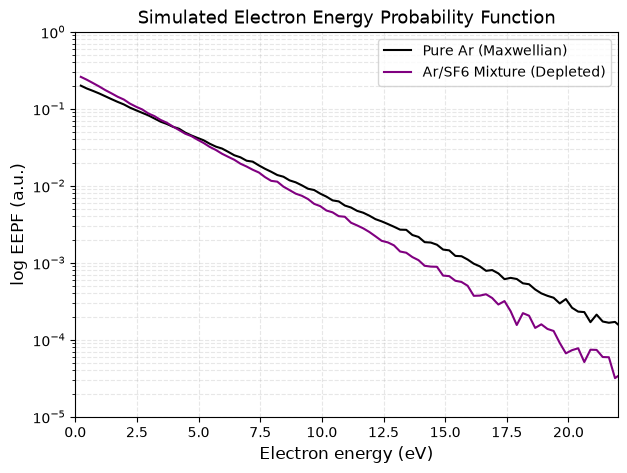

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# import scipy.constants as const

# def calculate_kinetic_energy(vx, vy, vz):
#     """
#     Calculates kinetic energy in electron-volts (eV) from 3D velocities.
#     """
#     v_squared = vx**2 + vy**2 + vz**2
#     # KE = 1/2 * m * v^2 (in Joules). Divide by 'e' to get eV.
#     ke_joules = 0.5 * const.m_e * v_squared
#     ke_ev = ke_joules / const.e
#     return ke_ev

# def get_eepf(energies_ev, bins=100, max_energy=25):
#     """
#     Converts a raw list of electron energies into an EEPF curve.
#     """
#     # 1. Create a histogram of the energies (This represents the EEDF)
#     eedf, bin_edges = np.histogram(energies_ev, bins=bins, range=(0.1, max_energy), density=True)
    
#     # Get the center of each bin for plotting
#     bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
#     # 2. Convert EEDF to EEPF by dividing by sqrt(Energy)
#     # The paper uses EEPF (eV^-3/2 cm^-3) because a Maxwellian distribution 
#     # appears as a straight line on a logarithmic EEPF plot.
    eepf = eedf / np.sqrt(bin_centers)
    
#     return bin_centers, eepf

# # ==========================================
# # 1. Simulate Electron Populations
# # ==========================================
# N_particles = 500000
# kT_eV = 3.0 # Average electron temperature (3 eV)

# # Thermal velocity based on temperature
# v_th = np.sqrt(2 * (kT_eV * const.e) / const.m_e)

# # Simulate Pure Argon (Standard Maxwellian Distribution)
# # In a real PIC-MCC code, these velocities would come from your solver's current timestep
# vx_ar = np.random.normal(0, v_th/np.sqrt(2), N_particles)
# vy_ar = np.random.normal(0, v_th/np.sqrt(2), N_particles)
# vz_ar = np.random.normal(0, v_th/np.sqrt(2), N_particles)
# energies_ar = calculate_kinetic_energy(vx_ar, vy_ar, vz_ar)

# # Simulate Ar/SF6 Mixture (Depleted tail due to inelastic collisions)
# # We mimic the physics of SF6 collisions by artificially depleting high-energy electrons
# vx_sf6 = np.random.normal(0, v_th/np.sqrt(2), N_particles)
# vy_sf6 = np.random.normal(0, v_th/np.sqrt(2), N_particles)
# vz_sf6 = np.random.normal(0, v_th/np.sqrt(2), N_particles)
# energies_sf6 = calculate_kinetic_energy(vx_sf6, vy_sf6, vz_sf6)

# # Apply a probability filter: high-energy electrons are lost to SF6 excitation/ionization
# # This mimics the Monte Carlo Collision (MCC) step in an advanced PIC code
survival_probability = np.exp(-energies_sf6 / 15.0) 
# random_chance = np.random.rand(N_particles)
# energies_sf6 = energies_sf6[random_chance < survival_probability]

# # ==========================================
# # 2. Process Data into EEPF
# # ==========================================
# energy_bins_ar, eepf_ar = get_eepf(energies_ar)
# energy_bins_sf6, eepf_sf6 = get_eepf(energies_sf6)

# # ==========================================
# # 3. Plot mimicking the Paper (Figure 2)
# # ==========================================
# fig, ax = plt.subplots(figsize=(7, 5), dpi=100)

# # Plot using a logarithmic Y-axis, just like the paper
# ax.semilogy(energy_bins_ar, eepf_ar, label='Pure Ar (Maxwellian)', color='black', linewidth=1.5)
# ax.semilogy(energy_bins_sf6, eepf_sf6, label='Ar/SF6 Mixture (Depleted)', color='purple', linewidth=1.5)

# ax.set_xlim(0, 22)
# ax.set_ylim(1e-5, 1)

# ax.set_xlabel("Electron energy (eV)", fontsize=12)
# ax.set_ylabel("log EEPF (a.u.)", fontsize=12)
# ax.set_title("Simulated Electron Energy Probability Function", fontsize=13)
# ax.legend()
# ax.grid(True, which="both", ls="--", alpha=0.3)

# plt.show()

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# import scipy.constants as const

# """
# 0D-3V PIC-MCC (Monte Carlo Collision) Simulation
# Simulates electron heating in an RF electric field and collisions 
# with Ar and SF6 neutral gas molecules to derive the EEPF.
# """

# # ==========================================
# # 1. Physical Constants & Simulation Params
# # ==========================================
# e = const.e
# m_e = const.m_e
# RF_FREQ = 13.56e6        # 13.56 MHz (Standard ICP frequency from paper)
# OMEGA = 2 * np.pi * RF_FREQ
# E0 = 600.0               # RF Electric field amplitude (V/m)

# # Time parameters
# dt = 1.0 / (OMEGA * 50)  # Resolve the RF cycle (50 steps per cycle)
# N_RF_CYCLES = 300        # Number of RF cycles to run to reach steady state
# N_STEPS = int((1.0 / RF_FREQ) * N_RF_CYCLES / dt)

# N_PARTICLES = 50000      # Number of simulated electrons 

# # ==========================================
# # 2. Collision Frequencies (Synthetic Cross-Sections)
# # ==========================================
# NU_AR_ELASTIC = 5e7      
# SF6_INELASTIC_THRES = 2.5 
# SF6_INELASTIC_LOSS = 2.0  
# NU_SF6_INELASTIC = 8e7    

# def get_collision_probs(energies_ev, sf6_fraction):
#     # 1. Argon Elastic 
#     p_ar_elastic = (1.0 - sf6_fraction) * NU_AR_ELASTIC * dt * np.ones_like(energies_ev)
    
#     # 2. SF6 Inelastic
#     p_sf6_inelastic = np.zeros_like(energies_ev)
#     mask_inelastic = energies_ev > SF6_INELASTIC_THRES
#     p_sf6_inelastic[mask_inelastic] = sf6_fraction * NU_SF6_INELASTIC * dt
    
#     # 3. SF6 Attachment (peaks heavily at very low energies)
#     p_sf6_attach = sf6_fraction * (1e7 * dt) / (energies_ev + 0.1) 
    
#     return p_ar_elastic, p_sf6_inelastic, p_sf6_attach

# def isotropic_scatter(v_mag):
#     phi = 2 * np.pi * np.random.rand(len(v_mag))
#     cos_theta = 1.0 - 2.0 * np.random.rand(len(v_mag))
#     sin_theta = np.sqrt(1.0 - cos_theta**2)
    
#     vx_new = v_mag * sin_theta * np.cos(phi)
#     vy_new = v_mag * sin_theta * np.sin(phi)
#     vz_new = v_mag * cos_theta
#     return vx_new, vy_new, vz_new

# # ==========================================
# # 3. Main PIC-MCC Engine (Now with Time-Averaging)
# # ==========================================
# def run_mcc_simulation(sf6_fraction):
#     print(f"Running simulation with {sf6_fraction*100}% SF6...")
    
#     # Initialize velocities
#     vx = np.random.normal(0, 1e5, N_PARTICLES)
#     vy = np.random.normal(0, 1e5, N_PARTICLES)
#     vz = np.random.normal(0, 1e5, N_PARTICLES)
#     active_mask = np.ones(N_PARTICLES, dtype=bool) 
    
#     # Array to store energies over the final RF cycles for smoothing
#     time_averaged_energies = []
#     start_averaging_step = int(0.8 * N_STEPS) # Start collecting data in the last 20% of time
    
#     # Time Integration Loop
#     for step in range(N_STEPS):
#         t = step * dt
        
#         # 1. E-Field Acceleration
#         E_t = E0 * np.sin(OMEGA * t)
#         vx[active_mask] += (-e * E_t / m_e) * dt
        
#         v_squared = vx**2 + vy**2 + vz**2
#         energies_ev = (0.5 * m_e * v_squared) / e
        
#         # 2. Monte Carlo Collisions
#         p_ar_el, p_sf6_inel, p_sf6_att = get_collision_probs(energies_ev, sf6_fraction)
#         rand_vals = np.random.rand(N_PARTICLES)
        
#         mask_attach = active_mask & (rand_vals < p_sf6_att)
#         active_mask[mask_attach] = False 
        
#         rand_vals -= p_sf6_att 
#         mask_inel = active_mask & (rand_vals < p_sf6_inel)
        
#         if np.any(mask_inel):
#             new_energies = np.maximum(0.01, energies_ev[mask_inel] - SF6_INELASTIC_LOSS)
#             new_v_mag = np.sqrt(new_energies * e * 2 / m_e)
#             vx[mask_inel], vy[mask_inel], vz[mask_inel] = isotropic_scatter(new_v_mag)
            
#         rand_vals -= p_sf6_inel
#         mask_el = active_mask & (rand_vals < p_ar_el) & ~mask_inel
        
#         if np.any(mask_el):
#             v_mag = np.sqrt(v_squared[mask_el])
#             vx[mask_el], vy[mask_el], vz[mask_el] = isotropic_scatter(v_mag)

#         # 3. Data Collection for Smoothing
#         # Instead of taking just the last frame, we collect particle energies over time
#         if step > start_averaging_step and step % 5 == 0:
#             surviving_v_sq = vx[active_mask]**2 + vy[active_mask]**2 + vz[active_mask]**2
#             time_averaged_energies.extend((0.5 * m_e * surviving_v_sq) / e)

#     return np.array(time_averaged_energies)

# # ==========================================
# # 4. Run and Plot Results
# # ==========================================
# energies_pure_ar = run_mcc_simulation(sf6_fraction=0.0)
# energies_mixture = run_mcc_simulation(sf6_fraction=0.4)

# def get_eepf(energies, bins=70, max_energy=22):
#     # Density=True normalizes the area under the curve to 1
#     eedf, bin_edges = np.histogram(energies, bins=bins, range=(0.1, max_energy), density=True)
#     bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
#     # Filter out empty bins to prevent massive vertical spikes on log plot!
#     valid_mask = eedf > 0
#     valid_centers = bin_centers[valid_mask]
#     valid_eedf = eedf[valid_mask]
    
#     eepf = valid_eedf / np.sqrt(valid_centers)
#     return valid_centers, eepf

# bins_ar, eepf_ar = get_eepf(energies_pure_ar)
# bins_mix, eepf_mix = get_eepf(energies_mixture)

# fig, ax = plt.subplots(figsize=(7, 5), dpi=100)

# ax.semilogy(bins_ar, eepf_ar, label='Pure Ar (0:10)', color='black', linewidth=1.5)
# ax.semilogy(bins_mix, eepf_mix, label='Ar/SF6 Mixture (4:6)', color='purple', linewidth=1.5)

# ax.set_xlim(0, 22)
# ax.set_ylim(1e-4, 1) # Raised the floor slightly to hide deep noise
# ax.set_xlabel("Electron energy (eV)", fontsize=12)
# ax.set_ylabel("log EEPF ($eV^{-3/2} cm^{-3}$)", fontsize=12)
# ax.set_title("Time-Averaged PIC-MCC Simulated EEPF", fontsize=13)
# ax.legend()
# ax.grid(True, which="both", ls="--", alpha=0.3)

# plt.show()

Running simulation with 0.0% SF6...
